In [1]:
import pandas as pd
import numpy as np
import os
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


from scipy.stats import pearsonr, spearmanr, ttest_rel, wilcoxon
from matplotlib import pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc


from Bio import pairwise2
from Bio.Seq import Seq
from Bio.Align import substitution_matrices
from Bio import SeqIO

from random import sample

plt.rcParams['svg.fonttype'] = 'none'

from utils_for_analysis import (
    calculate_ss_for_df_and_factors,
    load_df_all,
    load_df_with_budget,
    discretized_parameter_scale,
    xlabel_dict,
    ylabel_dict,
    title_fontsize,
    label_fontsize,
    tick_fontsize,
    legend_fontsize,
    original_parameter_scale,
    color_map,
    fix_ticks,
    get_labels,
    positions,
    num_muts_column_name,
    DATASET_PATHS,
    get_labels
)




/home/labs/fleishman/itayta/.conda/envs/esm_env/lib/python3.10/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [2]:
# Use the provided color map
color_map = {
    "esm_8m": "#002b87",
    "esm_35m": "#f0b800",
    "esm_150m": "#008230",    
    "esm_650m": "#bd0000",
    "esm_3b": "#00cfeb",
}

model_names_label_dict = {
    "esm_35m": "ESM2\n(35M)",
    "esm_8m": "ESM2\n(8M)",
    "esm_3b": "ESM2\n(3B)",
    "esm_150m": "ESM2\n(150m)",
    "esm_650m": "ESM2\n(650m)",
}

In [3]:
datasets = {"gcn4": "./data/gcn4/gcn4.csv",
            "pard3": "./data/pard3/pard3.csv"}

In [4]:
datasets = {
    "gcn4": {"path": "./data/gcn4/gcn4.csv", "activity_col": "activity"},
    "pard3": {"path": "./data/pard3/pard3.csv", "activity_col": "activity"}
}

def get_labels(df_name, discrete=False, df=None):
    if df is None:
        df = pd.read_csv(DATASET_PATHS[df_name])

    if df_name == "gfp":
        return((df["inactive"] == False).astype(int).to_numpy())

    activity_col_name = "p-nitrophenyl_acetate" if df_name == "pte" else "activity"
    labels = df[activity_col_name].astype(float).to_numpy()

    if discrete:
        return (labels > np.median(labels)).astype(int)

    return labels

In [5]:


records = []
for ds_name, ds in datasets.items():
    if ds_name == "gfp":
        continue
    
    datasets_path = f"./notebooks/{ds_name}/fitness_results/"
    df = pd.read_csv(ds["path"])

    normed_fitness = pd.read_csv(datasets_path + "normed_fitness_all.csv")
    fitness = pd.read_csv(datasets_path + "fitness_all.csv")
    act_col = ds["activity_col"]
    print(ds_name)

    for model in normed_fitness.columns:
        valid = (~df[act_col].isna()) & (~normed_fitness[model].isna())

        if valid.sum() > 0:
            corr, _ = spearmanr(normed_fitness[model][valid], df[act_col][valid])
            records.append(
                {
                    "dataset": ds_name,
                    "model": model,
                    "num_mutations": -1,
                    "correlation": corr,
                    "fitness_type": "normed_fitness"
                }
            )

        unique_mut = [v for v in df["num_muts"].dropna().unique() if v != 0]
        
        for nm in sorted(unique_mut):
            sel = (df["num_muts"] == nm) & (~df[act_col].isna()) & (~normed_fitness[model].isna())

            if sel.sum() > 0:
                corr, _ = spearmanr(normed_fitness[model][sel], df[act_col][sel])
                records.append(
                    {
                        "dataset": ds_name,
                        "model": model,
                        "num_mutations": nm,
                        "correlation": corr,
                        "fitness_type": "normed_fitness"
                    }
                )

    for model in fitness.columns:
        valid = (~df[act_col].isna()) & (~fitness[model].isna())
        if valid.sum() > 0:
            corr, _ = spearmanr(fitness[model][valid], df[act_col][valid])
            records.append(
                {
                    "dataset": ds_name,
                    "model": model,
                    "num_mutations": -1,
                    "correlation": corr,
                    "fitness_type": "fitness"
                }
            )
        unique_mut = df["num_muts"].dropna().unique()
        for nm in sorted(unique_mut):
            sel = (df["num_muts"] == nm) & (~df[act_col].isna()) & (~fitness[model].isna())
            if sel.sum() > 0:
                corr, _ = spearmanr(fitness[model][sel], df[act_col][sel])
                records.append(
                    {
                        "dataset": ds_name,
                        "model": model,
                        "num_mutations": nm,
                        "correlation": corr,
                        "fitness_type": "fitness"
                    }
                )

correlation_df = pd.DataFrame(records)


gcn4
pard3


In [7]:
from sklearn.metrics import roc_auc_score


records = []
percentiles = [0.25, 0.5, 0.75]

for ds_name, ds in datasets.items():
    datasets_path = f"./notebooks/{ds_name}/fitness_results/"
    df = pd.read_csv(ds["path"])
    normed_fitness = pd.read_csv(datasets_path + "normed_fitness_all.csv")
    fitness = pd.read_csv(datasets_path + "fitness_all.csv")
    act_col = ds["activity_col"]
    print(ds_name)

    if ds_name != "gfp":
        for perc in percentiles:
            threshold = df[act_col].quantile(perc)
            labels = (df[act_col] > threshold).astype(int)
            label_type = f"pct_{perc}"

            for model in normed_fitness.columns:
                valid = (~df[act_col].isna()) & (~normed_fitness[model].isna())
                if valid.sum() > 0 and labels[valid].nunique() == 2:
                    auc = roc_auc_score(labels[valid], normed_fitness[model][valid])
                    records.append({
                        "dataset": ds_name,
                        "model": model,
                        "num_mutations": -1,
                        "auc_roc": auc,
                        "label_type": label_type,
                        "fitness_type": "normed_fitness"
                    })

                unique_mut = [v for v in df["num_muts"].dropna().unique() if v != 0]
                for nm in sorted(unique_mut):
                    sel = (df["num_muts"] == nm) & (~df[act_col].isna()) & (~normed_fitness[model].isna())
                    if sel.sum() > 0 and labels[sel].nunique() == 2:
                        auc = roc_auc_score(labels[sel], normed_fitness[model][sel])
                        records.append({
                            "dataset": ds_name,
                            "model": model,
                            "num_mutations": nm,
                            "auc_roc": auc,
                            "label_type": label_type,
                            "fitness_type": "normed_fitness"
                        })

            for model in fitness.columns:
                valid = (~df[act_col].isna()) & (~fitness[model].isna())
                if valid.sum() > 0 and labels[valid].nunique() == 2:
                    auc = roc_auc_score(labels[valid], fitness[model][valid])
                    records.append({
                        "dataset": ds_name,
                        "model": model,
                        "num_mutations": -1,
                        "auc_roc": auc,
                        "label_type": label_type,
                        "fitness_type": "fitness"
                    })
                unique_mut = df["num_muts"].dropna().unique()
                for nm in sorted(unique_mut):
                    sel = (df["num_muts"] == nm) & (~df[act_col].isna()) & (~fitness[model].isna())
                    if sel.sum() > 0 and labels[sel].nunique() == 2:
                        auc = roc_auc_score(labels[sel], fitness[model][sel])
                        records.append({
                            "dataset": ds_name,
                            "model": model,
                            "num_mutations": nm,
                            "auc_roc": auc,
                            "label_type": label_type,
                            "fitness_type": "fitness"
                        })
    else:
        labels = (df["inactive"] == False).astype(int)
        label_type = "gfp_inactive_false"

        for model in normed_fitness.columns:
            valid = (~df["inactive"].isna()) & (~normed_fitness[model].isna())
            if valid.sum() > 0 and labels[valid].nunique() == 2:
                auc = roc_auc_score(labels[valid], normed_fitness[model][valid])
                records.append({
                    "dataset": ds_name,
                    "model": model,
                    "num_mutations": -1,
                    "auc_roc": auc,
                    "label_type": label_type,
                    "fitness_type": "normed_fitness"
                })

            unique_mut = [v for v in df["num_muts"].dropna().unique() if v != 0]
            for nm in sorted(unique_mut):
                sel = (df["num_muts"] == nm) & (~df["inactive"].isna()) & (~normed_fitness[model].isna())
                if sel.sum() > 0 and labels[sel].nunique() == 2:
                    auc = roc_auc_score(labels[sel], normed_fitness[model][sel])
                    records.append({
                        "dataset": ds_name,
                        "model": model,
                        "num_mutations": nm,
                        "auc_roc": auc,
                        "label_type": label_type,
                        "fitness_type": "normed_fitness"
                    })

        for model in fitness.columns:
            valid = (~df["inactive"].isna()) & (~fitness[model].isna())
            if valid.sum() > 0 and labels[valid].nunique() == 2:
                auc = roc_auc_score(labels[valid], fitness[model][valid])
                records.append({
                    "dataset": ds_name,
                    "model": model,
                    "num_mutations": -1,
                    "auc_roc": auc,
                    "label_type": label_type,
                    "fitness_type": "fitness"
                })
            unique_mut = df["num_muts"].dropna().unique()
            for nm in sorted(unique_mut):
                sel = (df["num_muts"] == nm) & (~df["inactive"].isna()) & (~fitness[model].isna())
                if sel.sum() > 0 and labels[sel].nunique() == 2:
                    auc = roc_auc_score(labels[sel], fitness[model][sel])
                    records.append({
                        "dataset": ds_name,
                        "model": model,
                        "num_mutations": nm,
                        "auc_roc": auc,
                        "label_type": label_type,
                        "fitness_type": "fitness"
                    })

auc_roc_df = pd.DataFrame(records)


gcn4
pard3


In [8]:
# For each model across all datasets, calculate the mean correlation for num_mutations == -1
models = [m for m in correlation_df['model'].unique() if m in color_map]



# For AUROC, subset by label_type as well (to match the plotting logic)
# This label_type variable is defined further below for plotting (set to e.g. "pct_0.5")

In [14]:
datasets_for_analysis = ["pard3", "gcn4"]
datasets_final = dict([(k,v) for k,v in DATASET_PATHS.items() if k in datasets_for_analysis])

In [15]:
pssm_comparision_results = []

for dataset, dataset_path in datasets_final.items():#dict([("lov", DATASET_PATHS["lov"])]).items():
    scores = []

    df = pd.read_csv(dataset_path)
    pssm = pd.read_csv(f"./data/{dataset}/pssm_scores.csv")
    wt_df = df[df[num_muts_column_name[dataset]] == 0]
    si = np.where(df.columns == positions[dataset][0])[0][0]
    ei = np.where(df.columns == positions[dataset][1])[0][0]+1
    dataset_positions = np.array([int(c[1:]) for c in df.columns[si:ei].tolist()]) - 1  # PDB BASED

    wt_seq = wt_df.iloc[:, si:ei].values[0]
    col_pos_in_pssm = np.array([np.where(seq_aa == pssm.columns)[0][0] for seq_aa in wt_seq])
    wt_score = pssm.values[dataset_positions, col_pos_in_pssm]

    nmuts = df[num_muts_column_name[dataset]].to_numpy()
    nmuts_with_zeros = nmuts.copy()
    nmuts_with_zeros[nmuts_with_zeros == 0] = 1

    for idx, row in df.iterrows():
        mut_seq = row.iloc[si:ei].values
        col_pos_in_pssm = np.array([np.where(seq_aa == pssm.columns)[0][0] for seq_aa in mut_seq])
        mut_score = pssm.values[dataset_positions, col_pos_in_pssm]
        exp_score = np.exp(mut_score)
        raw_score = np.sum(mut_score)
        avg_score = np.sum(mut_score / nmuts_with_zeros[idx])
        raw_fitness = np.sum(mut_score - wt_score)
        avg_fitness = np.sum((mut_score - wt_score) / nmuts_with_zeros[idx])
        scores.append([raw_score, avg_score, raw_fitness, avg_fitness])
        if idx % 1000 == 0:
            print(f"Processed {idx} rows")

    labels = get_labels(dataset)
    df_scores = pd.DataFrame(scores, columns=["raw_score", "avg_score", "raw_fitness", "avg_fitness"])
    all_nmuts = np.unique(nmuts)

    for discrete in [True, False]:
        if discrete:
            scoring_func = lambda y_true, y_pred: roc_auc_score(y_true, y_pred)
            comparison_type = "aucroc"
            y_labels = (labels > np.median(labels)).astype(int)
        else:
            if dataset == "gfp":
                continue

            scoring_func = lambda y_true, y_pred: spearmanr(y_true, y_pred)[0]
            comparison_type = "spearman"
            y_labels = labels

        # All nmuts aggregated, use mutations=-1
        for col in df_scores.columns:
            try:
                result_value = scoring_func(y_labels, df_scores[col])
            except Exception:
                result_value = None
            pssm_comparision_results.append({
                "dataset": dataset,
                "value": result_value,
                "comparision_type": comparison_type,
                "mutations": -1,
                "score_type": col
            })

        # Per nmuts group (skip nmuts==0)
        for specific_nmuts in all_nmuts:
            if specific_nmuts == 0:
                continue
            mask = nmuts == specific_nmuts
            if not np.any(mask):
                continue
            for col in df_scores.columns:
                try:
                    value = scoring_func(y_labels[mask], df_scores[col][mask])
                except Exception:
                    value = None
                pssm_comparision_results.append({
                    "dataset": dataset,
                    "value": value,
                    "comparision_type": comparison_type,
                    "mutations": int(specific_nmuts),
                    "score_type": col
                })

final_score_df = pd.DataFrame(pssm_comparision_results, columns=["dataset", "value", "comparision_type", "mutations", "score_type"])


Processed 0 rows
Processed 1000 rows
Processed 2000 rows
Processed 3000 rows
Processed 4000 rows
Processed 5000 rows
Processed 6000 rows
Processed 7000 rows
Processed 0 rows


/home/labs/fleishman/itayta/.conda/envs/esm_env/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/labs/fleishman/itayta/.conda/envs/esm_env/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/labs/fleishman/itayta/.conda/envs/esm_env/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/labs/fleishman/itayta/.conda/envs/esm_env/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/labs/fleishman/itayta/.conda/envs/esm_env/lib/python3.10/site-packages

In [16]:
final_score_df_pf = pd.DataFrame(pssm_comparision_results, columns=["dataset", "value", "comparision_type", "mutations", "score_type"])
final_score_df = final_score_df_pf[np.isin(final_score_df_pf["dataset"].values, np.array(datasets_for_analysis))]

In [17]:
use_auc = True  # If False, will plot Spearman correlation
label_type = "pct_0.5"  # Example: "pct_0.25" or any label_type in auc_roc_df; set None for all
datasets_to_use = datasets_for_analysis # , "pard3", "gcn4", "lov"]
fitness_type = "normed_fitness"
pssm_score_type = "avg_score"

if not use_auc:
    df_plot = correlation_df
    df_plot = df_plot[df_plot["fitness_type"] == fitness_type]
    df_plot = df_plot[df_plot["dataset"].isin(datasets_to_use)]
    value_col = 'correlation'
    ylabel = "Spearman's Rho"

    mean_corr_per_model = {}
    for m in models:
        corr_vals = df_plot[
            (df_plot['model'] == m) &
            (df_plot['num_mutations'] == -1)
        ]['correlation'].dropna()
        if len(corr_vals) > 0:
            mean_corr = corr_vals.mean()
        else:
            mean_corr = np.nan
        mean_corr_per_model[m] = mean_corr

    mean_dict = mean_corr_per_model
else:
    if label_type is not None:
        # Ensure to include all gfp rows regardless of label_type, then subset by datasets_to_use
        df_plot = pd.concat([
            auc_roc_df[(auc_roc_df["label_type"] == label_type) & (auc_roc_df["dataset"] != "gfp") & (auc_roc_df["fitness_type"] == fitness_type)],
            auc_roc_df[(auc_roc_df["dataset"] == "gfp") & (auc_roc_df["fitness_type"] == fitness_type)]
        ], ignore_index=True)
        df_plot = df_plot[df_plot["dataset"].isin(datasets_to_use)]
    else:
        df_plot = auc_roc_df
        df_plot = df_plot[df_plot["dataset"].isin(datasets_to_use)]
    value_col = 'auc_roc'
    ylabel = "ROC AUC"

    mean_auc_roc_per_model = {}
    for m in models:
        if 'label_type' in locals() and label_type is not None:
            auc_vals = df_plot[
                (df_plot['model'] == m) &
                (df_plot['num_mutations'] == -1) &
                ((df_plot['label_type'] == label_type) | (df_plot['dataset'] == "gfp"))
            ]['auc_roc'].dropna()
        else:
            auc_vals = df_plot[
                (df_plot['model'] == m) &
                (df_plot['num_mutations'] == -1)
            ]['auc_roc'].dropna()
        if len(auc_vals) > 0:
            mean_auc = auc_vals.mean()
        else:
            mean_auc = np.nan
        mean_auc_roc_per_model[m] = mean_auc
    mean_dict = mean_auc_roc_per_model
    vlim = (0, 1)


fix_auc_roc = True

if fix_auc_roc and use_auc:
    auc_roc = df_plot["auc_roc"]
    auc_roc[auc_roc < 0.5] = 1 - auc_roc[auc_roc < 0.5]

/tmp/ipykernel_32580/280273136.py:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  auc_roc[auc_roc < 0.5] = 1 - auc_roc[auc_roc < 0.5]


/tmp/ipykernel_32580/4253611629.py:106: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  auc_roc[(auc_roc < 0.5) & (final_score_df["comparision_type"] == "aucroc")] = 1 - auc_roc[(auc_roc < 0.5) & (final_score_df["comparision_type"] == "aucroc")]
/tmp/ipykernel_32580/4253611629.py:194: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.35)  # slightly reduce padding


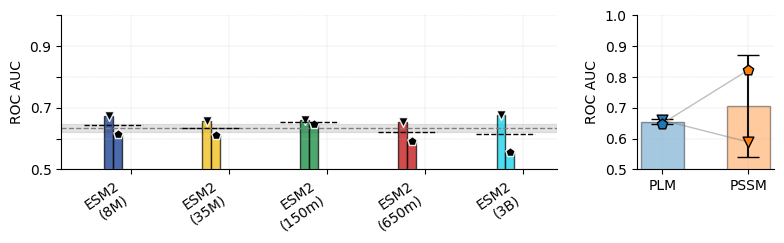

In [18]:

from matplotlib import gridspec

# -- Define fontsize variables (imported convention from classifier_over_embeddings.ipynb 15-19)
title_fontsize = 8
label_fontsize = 10
tick_fontsize = 10
legend_fontsize = 7

mutation_to_use = -1

models = [m for m in df_plot['model'].unique() if m in color_map]

fig = plt.figure(figsize=(9.2, 2))
gs = gridspec.GridSpec(1, 2, width_ratios=[7.2, 2.0], wspace=0.25)
ax_main = fig.add_subplot(gs[0, 0])
ax_paired = fig.add_subplot(gs[0, 1])

width = 0.09
x = np.arange(len(models))
pos_all = []

datasets_to_use = np.array(datasets_to_use)
datasets = datasets_to_use[np.argsort(datasets_to_use)]
dataset_markers = {
    "gfp": "o",
    "lov": "s",
    "pard3": "p",
    "nmt": "d",
    "gcn4": "v",
    "pte": "*",
    "his": "x",
    "casp": "+"
}

# Find which model has the max mean score (auc_roc or correlation) for num_mutations==-1
max_model = (df_plot[df_plot["num_mutations"] == -1]
             .groupby("model")["auc_roc" if use_auc else "correlation"]
             .mean()
             .idxmax())

# --- Grouped bar plot for all models/datasets (PLM) ---
for idx, ds in enumerate(datasets):
    means = []
    colors = []
    marker = dataset_markers[ds]
    for m in models:
        vals = df_plot[(df_plot['dataset'] == ds) & (df_plot['model'] == m) & (df_plot['num_mutations'] == mutation_to_use)][value_col]
        means.append(vals.values[0] if len(vals) > 0 else np.nan)
        colors.append(color_map.get(m, "#cccccc"))
    gap_width = width * 0.5
    if idx < 3:
        pos = x + (idx - 2.5) * width
    else:
        pos = x + (idx - 2.5) * width + gap_width
    bars = ax_main.bar(
        pos,
        means,
        width=width,
        label=ds,
        color=colors,
        edgecolor='black',
        linewidth=1.0,
        alpha=0.7
    )
    ax_main.scatter(
        pos, 
        means, 
        marker=marker, 
        facecolor='black', 
        linewidth=1,
        edgecolor=(1, 1, 1, 0.9),  # white outline with some opacity
        s=50, 
        zorder=10
    )
    pos_all.append(pos)

mean_pos = np.array(pos_all).mean(axis=0)
for i, m in enumerate(models):
    y = mean_dict.get(m, np.nan)
    if not np.isnan(y):
        ax_main.hlines(y, mean_pos[i]-0.3, mean_pos[i]+0.3, color='k', lw=1, zorder=10, linestyles='dashed')

ax_main.set_ylabel(ylabel, fontsize=label_fontsize)
ax_main.set_xticks(x)
# Use model_names_label_dict for xticklabels:
xticklabels = [model_names_label_dict.get(m, m) for m in models]
ax_main.set_xticklabels(xticklabels, rotation=35, ha='right', fontsize=tick_fontsize)
ax_main.tick_params(axis='y', labelsize=tick_fontsize)

mean_cor = np.nanmean(list(mean_dict.values()))
std_cor = np.nanstd(list(mean_dict.values()))
ax_main.axhspan(mean_cor - std_cor, mean_cor + std_cor, color="gray", alpha=0.2, zorder=0, label=None)
ax_main.axhline(mean_cor, color="gray", linestyle="--", linewidth=1, zorder=1)
ax_main.axhline(0, color="black", linewidth=1, zorder=1)

# From classifier_over_embeddings.ipynb lines 43-48:
ax_main.grid(True, which='both', linestyle='--', linewidth=0.25, alpha=0.7)
ax_main.spines['right'].set_visible(False)
ax_main.spines['top'].set_visible(False)

# --- Paired dots/lines PLM vs PSSM (right) ---
comp_type = "aucroc" if use_auc else "spearman"

if fix_auc_roc and use_auc:
    auc_roc = final_score_df["value"]
    auc_roc[(auc_roc < 0.5) & (final_score_df["comparision_type"] == "aucroc")] = 1 - auc_roc[(auc_roc < 0.5) & (final_score_df["comparision_type"] == "aucroc")]

pssm_df = final_score_df[(final_score_df["mutations"] == mutation_to_use) &
                         (final_score_df["comparision_type"] == comp_type) &
                        (final_score_df["score_type"] == pssm_score_type)]

best_plm_df = df_plot[(df_plot["model"] == max_model) & (df_plot["num_mutations"] == mutation_to_use)]

col_name = "auc_roc" if use_auc else "correlation"

pssm_df = pssm_df.iloc[np.argsort(pssm_df["dataset"].tolist())]
best_plm_df = best_plm_df.iloc[np.argsort(best_plm_df["dataset"].tolist())]

assert (best_plm_df["dataset"].to_numpy() == pssm_df["dataset"].to_numpy()).all()

plm_auc = best_plm_df[col_name].to_numpy()
pssm_auc = pssm_df["value"].to_numpy()
means = [plm_auc.mean(), pssm_auc.mean()]
stds = [plm_auc.std(ddof=1), pssm_auc.std(ddof=1)]

bar_x = [1, 2]
bar_width = 0.5

bars = ax_paired.bar(
    bar_x,
    means,
    yerr=stds,
    width=bar_width,
    color=['tab:blue', 'tab:orange'],
    edgecolor='black',
    alpha=0.4,
    capsize=8,
    zorder=1
)

# Overlay the same dataset markers on the paired plot
for idx, ds in enumerate(pssm_df["dataset"]):
    marker = dataset_markers[ds]
    x1 = 1
    x2 = 2
    ax_paired.scatter(x1, plm_auc[idx], marker=marker, color='tab:blue', s=60, zorder=3, edgecolor='black', label=None)
    ax_paired.scatter(x2, pssm_auc[idx], marker=marker, color='tab:orange', s=60, zorder=3, edgecolor='black', label=None)
    ax_paired.plot([x1, x2], [plm_auc[idx], pssm_auc[idx]], color='gray', lw=1, alpha=0.5, zorder=2)

ax_paired.set_xticks([1, 2])
ax_paired.set_xticklabels(['PLM', 'PSSM'], rotation=0, fontsize=tick_fontsize)
ax_paired.grid(axis='y', linestyle='--', alpha=0.5)
ax_paired.set_xlim(0.7, 2.3)
ax_paired.set_ylabel("", fontsize=label_fontsize)
ax_paired.tick_params(axis='y', labelsize=tick_fontsize)

# Corresponding from classifier_over_embeddings.ipynb lines 43-48:
ax_paired.grid(True, which='both', linestyle='--', linewidth=0.25, alpha=0.7)
ax_paired.spines['right'].set_visible(False)
ax_paired.spines['top'].set_visible(False)

miny = min(min(pssm_df["value"]), min(best_plm_df[col_name]))
maxy = max(max(pssm_df["value"]), max(best_plm_df[col_name]))

if col_name == "correlation":
    ax_main.set_ylim(-0.25, 1)
    pass
else:
    ax_paired.set_ylim(0.5 ,1)
    ax_main.set_ylim(0.5 ,1)
    #ax_paired.set_xticklabels([])
    #ax_main.set_xticklabels([])
ax_paired.set_ylabel(ylabel, fontsize=label_fontsize)

# Paired t-test/Wilcoxon
t_stat, t_p = ttest_rel(plm_auc, pssm_auc)
try:
    w_stat, w_p = wilcoxon(plm_auc, pssm_auc)
except ValueError:
    w_stat, w_p = np.nan, np.nan

# Annotate stats in paired plot
ymax = max(np.max(plm_auc), np.max(pssm_auc), max(means + [m + s for m, s in zip(means, stds)])) + 0.02
x_annot = 1.5
# ax_paired.text(x_annot, ymax, f"Paired t-test p={t_p:.3g}\nWilcoxon p={w_p:.3g}",
#         ha='center', va='bottom', fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

fix_ticks(ax_main, x=False, y=True, every_other=True,fontsize=tick_fontsize)
#fix_ticks(ax_paired, x=False, y=True, every_other=True,fontsize=tick_fontsize)

os.makedirs("./refined_figures/figure_zero_shot", exist_ok=True)

# The order of the following matters for correct tight bounding boxes
plt.tight_layout(pad=0.35)  # slightly reduce padding

# Use fig.patch to set background transparent (so export is clean even if notebook bg is not white)
fig.patch.set_facecolor('white')

# Use bbox_inches='tight' AND pad_inches=0 when saving, to ensure absolutely no extra margin or cropping and figure is tightly clipped (no matplotlib outer frame)
fig.savefig(
    "./refined_figures/figure_zero_shot/%s_plot.svg" % (comp_type), 
    bbox_inches='tight',   # tightly fit content to canvas
    pad_inches=0,
    transparent=False
)

plt.show()

/tmp/ipykernel_32580/1090457624.py:140: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


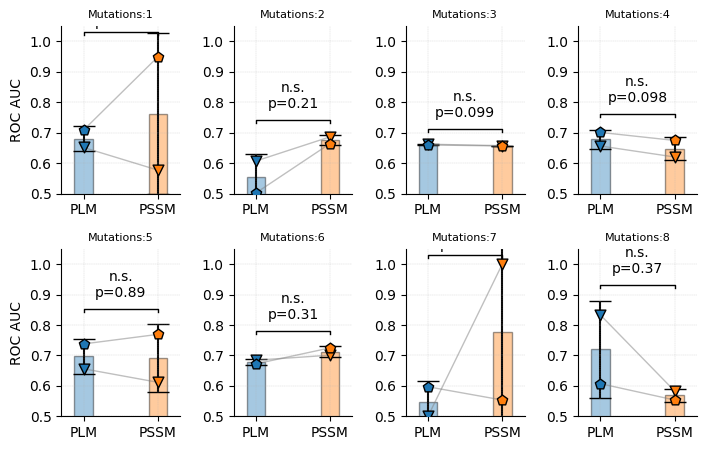

In [19]:

# --- Huge subplot: PLM vs PSSM across mutations (1-8), subplot per mutation ---
from matplotlib.gridspec import GridSpec
from scipy.stats import ttest_rel  # Only paired t-test needed

mutation_range = range(1, 9)
n_mut = len(mutation_range)

# Redefine subplot grid: 2 rows x 4 cols
n_rows, n_cols = 2, 4
fig_huge = plt.figure(figsize=(8.2, 5))
gs_huge = GridSpec(
    n_rows,
    n_cols,
    figure=fig_huge,
    wspace=0.45,  # Increased margin between columns (was 0.25)
    hspace=0.33
)

paired_means = []
paired_stds = []

def format_p_value(p):
    if np.isnan(p):
        return "NaN"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "n.s."

def format_p_value_numeric(p):
    return f"{p:.2g}" if not np.isnan(p) else "NaN"

for i, mut in enumerate(mutation_range):
    row = i // n_cols
    col = i % n_cols
    ax = fig_huge.add_subplot(gs_huge[row, col])
    # Select data for this mutation for both PLM and PSSM
    pssm_sub = final_score_df[
        (final_score_df["mutations"] == mut) &
        (final_score_df["comparision_type"] == comp_type) &
        (final_score_df["score_type"] == pssm_score_type)
    ].dropna()
    plm_sub = df_plot[
        (df_plot["model"] == max_model) &
        (df_plot["num_mutations"] == mut)
    ].dropna()
    # Common datasets only
    common_datasets = sorted(set(pssm_sub["dataset"]).intersection(set(plm_sub["dataset"])))
    if not common_datasets:  # Skip if none
        continue
    pssm_sub = pssm_sub[pssm_sub["dataset"].isin(common_datasets)]
    plm_sub = plm_sub[plm_sub["dataset"].isin(common_datasets)]
    # Sort both dataframes by dataset for direct matching
    pssm_sub = pssm_sub.set_index("dataset").loc[common_datasets].reset_index()
    plm_sub = plm_sub.set_index("dataset").loc[common_datasets].reset_index()

    plm_vals = plm_sub[col_name].values
    pssm_vals = pssm_sub["value"].values

    # If plotting auc_roc, apply correction: if < 0.5, set to 1 - value
    if col_name == "auc_roc":
        plm_vals = plm_vals.copy()
        pssm_vals = pssm_vals.copy()
        plm_vals = np.where(plm_vals < 0.5, 1 - plm_vals, plm_vals)
        pssm_vals = np.where(pssm_vals < 0.5, 1 - pssm_vals, pssm_vals)

    # Perform paired t-test only
    t_p = np.nan
    t_stat = np.nan
    try:
        t_stat, t_p = ttest_rel(plm_vals, pssm_vals)
    except Exception:
        t_p = np.nan

    # Bar plot (mean +/- std) - narrower bars, width=0.25
    means = [np.mean(plm_vals), np.mean(pssm_vals)]
    stds = [np.std(plm_vals, ddof=1), np.std(pssm_vals, ddof=1)]
    paired_means.append(means)
    paired_stds.append(stds)

    b = ax.bar(
        [1, 2], means, width=0.25, yerr=stds,
        color=['tab:blue', 'tab:orange'],
        edgecolor='black', alpha=0.4, capsize=8, zorder=1
    )

    # Overlay dataset points + paired lines
    for idx, ds in enumerate(common_datasets):
        marker = dataset_markers.get(ds, 'o')
        x1, x2 = 1, 2
        ax.scatter(x1, plm_vals[idx], marker=marker, color='tab:blue', s=60, zorder=3, edgecolor='black', label=None, clip_on=True)
        ax.scatter(x2, pssm_vals[idx], marker=marker, color='tab:orange', s=60, zorder=3, edgecolor='black', label=None, clip_on=True)
        ax.plot([x1, x2], [plm_vals[idx], pssm_vals[idx]], color='gray', lw=1, alpha=0.5, zorder=2, clip_on=True)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['PLM', 'PSSM'], rotation=0, fontsize=tick_fontsize)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_xlim(0.7, 2.3)
    # Set y-axis label on the first column only
    if col == 0:
        ax.set_ylabel(ylabel, fontsize=label_fontsize)
    else:
        ax.set_ylabel("")
    ax.tick_params(axis='y', labelsize=tick_fontsize)

    # From classifier_over_embeddings.ipynb lines 43-48:
    ax.grid(True, which='both', linestyle='--', linewidth=0.25, alpha=0.7)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # Y-limits
    if col_name == "correlation":
        pass
    else:
        ax.set_ylim(0.5, 1.05)

    # Annotate paired t-test significance above the bars
    # Find max y for annotation
    max_bar_height = max(means[i] + stds[i] for i in range(2))
    y_annot = max_bar_height + 0.05  # some offset

    # Constrain annotation line and text inside axes
    y_annot = min(y_annot, ax.get_ylim()[1] - 0.02)
    # Draw annotation line between bars with clip_on
    ax.plot([1, 1, 2, 2], [y_annot-0.01, y_annot, y_annot, y_annot-0.01], color='k', linewidth=1, clip_on=True)
    # Display p-value symbol and numeric value (also limit within y-axis)
    pval_symbol = format_p_value(t_p)
    pval_numeric = format_p_value_numeric(t_p)
    y_text = min(y_annot + 0.03, ax.get_ylim()[1] - 0.01)
    ax.text(1.5, y_text, f"{pval_symbol}\np={pval_numeric}", ha='center', va='bottom', fontsize=10, clip_on=True)
    # Title
    ax.set_title(f"Mutations:{mut}", fontsize=title_fontsize)

# Super-title or layout adjustments

# Remove superfluous padding and prevent plotting outside axis
plt.tight_layout()
plt.subplots_adjust(top=0.89)
fig_huge.patch.set_alpha(1)                # White background, not transparent
for ax in fig_huge.axes:
    ax.set_clip_on(True)
    # Force all children artists inside axes:
    for item in ax.get_children():
        if hasattr(item, 'set_clip_on'):
            item.set_clip_on(True)
plt.savefig('./refined_figures/figure_zero_shot/paired_paired_mut_subplot_%s.svg' % (comp_type),
            bbox_inches='tight', pad_inches=0, transparent=False)
plt.show()


/tmp/ipykernel_32580/2740291873.py:23: RuntimeWarning: invalid value encountered in log
  x_vals = np.log(labels)
/tmp/ipykernel_32580/2740291873.py:23: RuntimeWarning: invalid value encountered in log
  x_vals = np.log(labels)
/tmp/ipykernel_32580/2740291873.py:23: RuntimeWarning: invalid value encountered in log
  x_vals = np.log(labels)
/tmp/ipykernel_32580/2740291873.py:23: RuntimeWarning: invalid value encountered in log
  x_vals = np.log(labels)
/tmp/ipykernel_32580/2740291873.py:23: RuntimeWarning: invalid value encountered in log
  x_vals = np.log(labels)
/tmp/ipykernel_32580/2740291873.py:23: RuntimeWarning: invalid value encountered in log
  x_vals = np.log(labels)
/tmp/ipykernel_32580/2740291873.py:23: RuntimeWarning: invalid value encountered in log
  x_vals = np.log(labels)


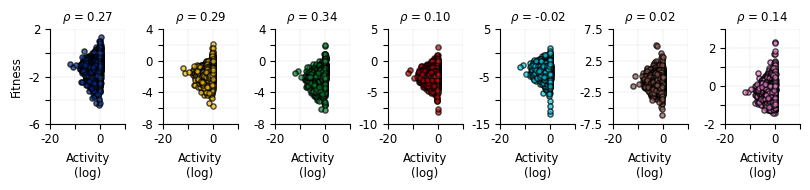

/tmp/ipykernel_32580/2740291873.py:23: RuntimeWarning: divide by zero encountered in log
  x_vals = np.log(labels)
/tmp/ipykernel_32580/2740291873.py:23: RuntimeWarning: divide by zero encountered in log
  x_vals = np.log(labels)
/tmp/ipykernel_32580/2740291873.py:23: RuntimeWarning: divide by zero encountered in log
  x_vals = np.log(labels)
/tmp/ipykernel_32580/2740291873.py:23: RuntimeWarning: divide by zero encountered in log
  x_vals = np.log(labels)
/tmp/ipykernel_32580/2740291873.py:23: RuntimeWarning: divide by zero encountered in log
  x_vals = np.log(labels)
/tmp/ipykernel_32580/2740291873.py:23: RuntimeWarning: divide by zero encountered in log
  x_vals = np.log(labels)
/tmp/ipykernel_32580/2740291873.py:23: RuntimeWarning: divide by zero encountered in log
  x_vals = np.log(labels)


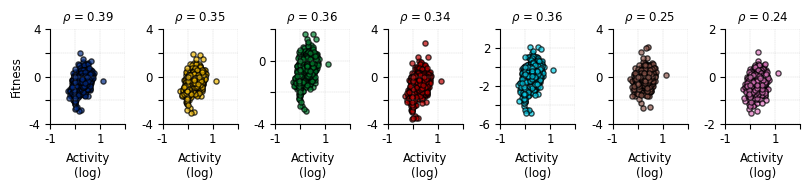

In [20]:
records = []
for ds_name, ds in datasets_final.items():
    df = pd.read_csv(ds)
    datasets_path = f"./notebooks/{ds_name}/fitness_results/"
    normed_fitness = pd.read_csv(datasets_path + "normed_fitness_all.csv")
    labels = get_labels(ds_name)

    if ds_name == "gfp":
        continue
    
    title_fontsize = 8.5
    label_fontsize = 8.5
    tick_fontsize = 8.5
    legend_fontsize = 7

    num_cols = normed_fitness.shape[1]
    fig, axes = plt.subplots(1, num_cols, figsize=(8.2, 2), squeeze=False)
    axes = axes[0]  # 1 row

    for idx, col in enumerate(normed_fitness.columns):
        ax = axes[idx]
        y_vals = normed_fitness[col].values
        x_vals = np.log(labels)
        # color_map assumed provided in context: mapping col to a color, e.g. {"aucroc": "blue", ...}
        color = color_map[col] if 'color_map' in locals() and col in color_map else 'C%d' % idx

        # Scatter plot with decreased marker size
        scatter = ax.scatter(x_vals, y_vals, color=color, alpha=0.7, s=14, edgecolor='k')
        ax.set_xlabel('Activity\n(log)', fontsize=label_fontsize)

        if idx == 0:
            ax.set_ylabel("Fitness", fontsize=label_fontsize)
        else:
            ax.set_ylabel("")

        # Add: Corresponding from classifier_over_embeddings.ipynb lines 43-48:
        ax.grid(True, which='both', linestyle='--', linewidth=0.25, alpha=0.7)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)

        # Calculate Spearman correlation
        mask = ~(np.isnan(x_vals) | np.isnan(y_vals))
        if np.any(mask):
            corr, pval = spearmanr(x_vals[mask], y_vals[mask])
            spearman_str = f"$\\rho$ = {corr:.2f}"
        else:
            spearman_str = "S$\\rho$ = n/a"

        # Place on top of each subplot
        ax.set_title(spearman_str, fontsize=title_fontsize)

        fix_ticks(ax, x=True, y=True, every_other=True, fontsize=tick_fontsize)

    plt.tight_layout(w_pad=0.2)  # Reduce horizontal spacing between subplots
    plt.subplots_adjust(wspace=0.5)  # Fine-tune spacing further if needed
    output_dir = "./refined_figures/figure_zero_shot"
    os.makedirs(output_dir, exist_ok=True)
    fig.savefig(os.path.join(output_dir, f"{ds_name}_raw_activity_corplot.svg"), bbox_inches='tight')
    plt.show()

/tmp/ipykernel_32580/2668544540.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Inactive', 'Active'], rotation=45, fontsize=tick_fontsize)
/tmp/ipykernel_32580/2668544540.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Inactive', 'Active'], rotation=45, fontsize=tick_fontsize)
/tmp/ipykernel_32580/2668544540.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Inactive', 'Active'], rotation=45, fontsize=tick_fontsize)
/tmp/ipykernel_32580/2668544540.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Inactive', 'Active'], rotation=45, fontsize=tick_fontsize)
/tmp

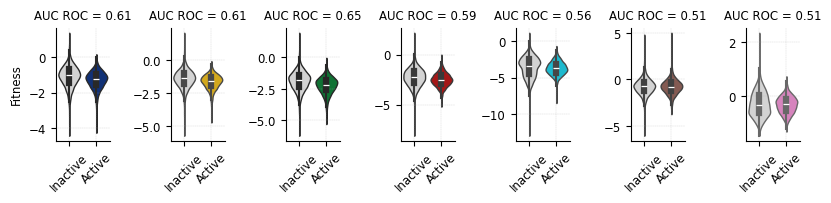

/tmp/ipykernel_32580/2668544540.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Inactive', 'Active'], rotation=45, fontsize=tick_fontsize)
/tmp/ipykernel_32580/2668544540.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Inactive', 'Active'], rotation=45, fontsize=tick_fontsize)
/tmp/ipykernel_32580/2668544540.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Inactive', 'Active'], rotation=45, fontsize=tick_fontsize)
/tmp/ipykernel_32580/2668544540.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Inactive', 'Active'], rotation=45, fontsize=tick_fontsize)
/tmp

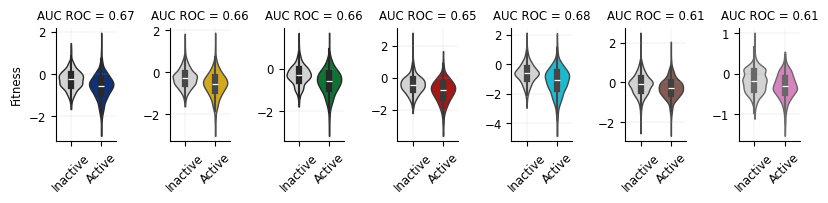

In [21]:
import seaborn as sns
from sklearn.metrics import roc_auc_score

records = []

inactive_color = "lightgray"

for ds_name, ds in datasets_final.items():
    df = pd.read_csv(ds)
    datasets_path = f"./notebooks/{ds_name}/fitness_results/"
    normed_fitness = pd.read_csv(datasets_path + "normed_fitness_all.csv")
    y_true = get_labels(ds_name, discrete=True)
    y_true = pd.Series(y_true)

    # Font sizes, match style conventions
    title_fontsize = 8.5
    label_fontsize = 8.5
    tick_fontsize = 8.5
    legend_fontsize = 7

    columns = normed_fitness.columns
    fig, axes = plt.subplots(1, len(columns), figsize=(8.2, 2.25), squeeze=False)
    axes = axes[0]  # Make it flat for easy indexing

    for i, col in enumerate(columns):
        ax = axes[i]

        # Palette: Inactive fixed color, Active gets mapped per color_map/standard color
        if 'color_map' in locals() and col in color_map:
            active_color = color_map[col]
        else:
            active_color = f'C{i}'  # consistent with previous conventions

        # DataFrame for plotting
        data_plot = pd.DataFrame({
            'Fitness': normed_fitness[col],
            'Label': y_true.map({0: 'Inactive', 1: 'Active'})
        })

        palette = [inactive_color, active_color]

        # Use @file_context_0: replace col with readable label if available
        plot_title = model_names_label_dict[col] if col in model_names_label_dict else col

        # --- Calculate AUC ROC, similar to plm_zero_shot.ipynb (42-51) convention ---
        # Use the normalized fitness scores to predict binary y_true
        x_vals = normed_fitness[col].values
        mask = ~(np.isnan(x_vals) | np.isnan(y_true.values))
        if np.any(mask) and (len(np.unique(y_true[mask])) > 1):  # Must have at least 2 classes for AUC
            auc_roc = roc_auc_score(y_true[mask], x_vals[mask])
            auc_roc = 1 - auc_roc if auc_roc < 0.5 else auc_roc
            auc_str = f"AUC ROC = {auc_roc:.2f}"
        else:
            auc_str = "AUC ROC = n/a"

        # Violinplot, match style (removed legend key, for clarity)
        sns.violinplot(
            data=data_plot,
            x='Label',
            y='Fitness',
            hue='Label',
            ax=ax,
            palette=palette,
            cut=0,
            linewidth=1,
            inner="box"
        )

        # @file_context_1: add consistent grid and spine formatting
        ax.grid(True, which='both', linestyle='--', linewidth=0.25, alpha=0.7)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)

        # Format axes and labels
        ax.set_xticklabels(['Inactive', 'Active'], rotation=45, fontsize=tick_fontsize)
        ax.tick_params(axis='both', labelsize=tick_fontsize)

        if i == 0:
            ax.set_ylabel("Fitness", fontsize=label_fontsize)
        else:
            ax.set_ylabel("", fontsize=label_fontsize)
        ax.set_xlabel("", fontsize=label_fontsize)

        # Set plot title showing readable label + auc
        ax.set_title(f"{auc_str}", fontsize=title_fontsize)

        # Remove default legend if seaborn adds it, to match style
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    # Output figure with clear naming and written to correct location
    output_dir = "./refined_figures/figure_zero_shot"
    os.makedirs(output_dir, exist_ok=True)
    fig.savefig(os.path.join(output_dir, f"{ds_name}_raw_activity_violinplot.svg"), bbox_inches='tight')